## Feature engineering with Python

Overview
The data we will use in this notebook is customer data from a European bank. We will compare the performance of different models on this data. 
The data will be used to predict whether a customer of the bank will churn. If a customer churns, it means they left the bank and took their business elsewhere. If we can predict which customers are likely to churn, we can take measures to retain them before they do.

Topics of focus in this activity include:

1. Feature selection
- Removing uninformative features
2. Feature extraction
- Creating new features from existing features
3. Feature transformation
- Modifying existing features to better suit our objectives
- Encoding of categorical features as dummies

In [3]:
#Import Packages
import numpy as np
import pandas as pd

**Target variable**
The data dictionary shows that there is a column called Exited. This is a Boolean value that indicates whether or not a customer left the bank (0 = did not leave, 1 = did leave). This will be our target variable. In other words, for each customer, our model should predict whether they should have a 0 or a 1 in the Exited column.

This is a supervised learning classification task because we will predict on a binary class. Therefore, this notebook will prepare the data for a classification model.

To begin, we will read in the data from a .csv file. Then, we will briefly examine it to better understand what it is telling us.

In [5]:
#Read the data file
df_original = pd.read_csv('Churn_Modelling.csv')
df_original.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


When modeling, a best practice is to perform a rigorous examination of the data before beginning feature engineering and feature selection. Not only does this process help you understand your data, what it is telling you, and what it is not telling you, but it also can give you clues that help you create new features.

The following table provides a quick overview of the data:

In [6]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 976.6 KB


From this table, we can confirm that the data has 14 features and 10,000 observations. We also know that nine features are integers, two are floats, and three are strings. Finally, we can tell that there are no null values because there are 10,000 observations, and each column has 10,000 non-null values.

## Feature selection

Feature selection is the process of choosing features to be used for modeling. In practice, feature selection takes place at multiple points in the PACE process. Although sometimes we will be given a dataset and a defined target variable, most often in practice we will begin with only a question or a problem that we are tasked with solving. In these cases, if we decide that the problem requires a model, we will then have to:

1. Consider what data is available 
2. Decide on what kind of model needed
3. Decide on a target variable
4. Assemble a collection of features that might help predict on  chosen target
This all takes place during the **Plan** phase.

Then, during the **Analyze** phase,  perform EDA on the data and reevaluate variables for appropriateness. For example, can my model handle null values? If not, what do I do with features with a lot of nulls? Perhaps I drop them. This too is feature selection.

Feature selection also occurs during the Construct phase. This usually involves building a model, examining which features are most predictive, and then removing the unpredictive features.

There's a lot of work involved in feature selection. In this case, we already have a dataset, and we are not performing thorough EDA on it. However, we can still examine the data to ensure that all the features can reasonably be expected to have predictive potential.

Returning to the bank data, notice that the first column is called RowNumber, and it just enumerates the rows. We should drop this feature, because row number shouldn't have any correlation with whether or not a customer churned.

The same is true for CustomerID, which appears to be a number assigned to the customer for administrative purposes, and Surname, which is the customer's last name. Since these cannot be expected to have any influence over the target variable, we can remove them from the modeling dataset.

Finally, for ethical reasons, we should remove the Gender column. The reason for doing this is that we don't want our model-making predictions (and therefore, offering promotions/financial incentives) based on a person's gender.

In [9]:
# Create a new df that drops RowNumber, CustomerId, Surname, and Gender cols
churn_df = df_original.drop(['RowNumber', 'CustomerId', 'Surname', 'Gender'], axis = 1)

In [10]:
churn_df.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0
2,502,France,42,8,159660.80,3,1,0,113931.57,1
3,699,France,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0


**Feature extraction**
Depending on data, we may be able to create brand new features from our existing features. Oftentimes, features that we create  are some of the most important features selected by my model. Usually this is the case when we have both domain knowledge for the problem we're solving and the right combinations of data.

For example, suppose we knew that our bank had a computer glitch that caused many credit card transactions to be mistakenly declined in October. It would be reasonable to suspect that people who experienced this might be at increased risk of leaving the bank. If we had a feature that represented each customer's number of credit card transactions each month, we could create a new feature; for example, OctUseRatio, where:

 $OctUseRatio = \frac{num of Oct. transactions}{avg num monthly transactions}$

This new feature would then give  a ratio that might be indicative of whether the customer experienced declined transactions.

We don't have this kind of specific circumstantial knowledge, and we don't have many features to choose from, but we can create a new feature that might help improve the model.

Let's create a Loyalty feature that represents the percentage of each customer's life that they were customers. We can do this by dividing Tenure by Age:
 $Loyalty = \frac{Tenure}{Age}$
 
The intuition here is that people who have been customers for a greater proportion of their lives might be less likely to churn.

In [11]:
# Create Loyalty variable
churn_df['Loyalty'] = churn_df['Tenure'] / churn_df['Age'] 
churn_df.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Loyalty
0,619,France,42,2,0.00,1,1,1,101348.88,1,0.047619
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0,0.024390
2,502,France,42,8,159660.80,3,1,0,113931.57,1,0.190476
3,699,France,39,1,0.00,2,0,0,93826.63,0,0.025641
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0,0.046512


**Feature transformation**
The next step is to transform our features to get them ready for modeling. Different models have different requirements for how the data should be prepared and also different assumptions about their distributions, independence, and so on.

The models we will be building with this data are all classification models, and classification models generally need categorical variables to be encoded. Our dataset has one categorical feature: Geography. Let's check how many categories appear in the data for this feature.

In [12]:
# Print unique values of Geography col
churn_df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

There are three unique values: France, Spain, and Germany. Encode this data so it can be represented using Boolean features. We will use a pandas function called **pd.get_dummies()** to do this.

When we call pd.get_dummies() on this feature, it will replace the Geography column with three new Boolean columns--one for each possible category contained in the column being dummied.

When we specify drop_first=True in the function call, it means that instead of replacing Geography with three new columns, it will instead replace it with two columns. We can do this because no information is lost from this, but the dataset is shorter and simpler.

In this case, we end up with two new columns called Geography_Germany and Geography_Spain. We don't need a Geography_France column, because if a customer's values in Geography_Germany and Geography_Spain are both 0, we will know they are from France!

In [13]:
# Encode the variables using pd.get_dummies
churn_df = pd.get_dummies(churn_df, drop_first = True)
churn_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Loyalty,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0.047619,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.024390,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,0.190476,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.025641,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,0.046512,False,True


We can now use our new dataset to build a model.

## Naive Bayes
Topics of focus include:

Relevant import statements
Stratification during data splitting
Fitting a Naive Bayes model
Evaluating the model on test data

**Modeling objective**
The modeling objective is to build and test a **Naive Bayes model** that uses banking data to predict whether a customer will churn. If a customer churns, it means they left the bank and took their business elsewhere. If we can predict customers who are likely to churn, we can take measures to retain them before they do. These measures could be promotions, discounts, or other incentives to boost customer satisfaction and, therefore, retention.

**Target variable**
Remember, our target variable is called **Exited**. This is a Boolean value that indicates whether or not a customer left the bank (0 = did not leave, 1 = did leave). For each customer, our model will predict whether they should have a 0 or a 1 in the Exited column.

**IMPORTANT: Model design**
This is a classification task, because we are trying to predict on a binary class. Naive Bayes often works well for this kind of task. However, recall that there are several different implementations of the Naive Bayes algorithm in scikit-learn, and each assumes that all of your predictor variables are of a single type (e.g., Gaussian for continuous variables, Bernoulli for binary variables, etc.).

Our data has all different types of predictor variables! As a data professional, one of the first things you'll learn on the job is that real-world data is never perfect. Sometimes the data breaks the assumptions of your model. In practice, you'll have to do the best you can with what you have.

In this case, if we wanted to build the best possible Naive Bayes model, we'd treat each variable according to their different types and distributions, and then combine each conditional probability to get the final prediction for each observation. That's advanced data science, and beyond the scope of this course.

For this lesson, we're going to use the GaussianNB classifier. This implementation assumes that all of your variables are continuous and that they have a Gaussian (i.e., normal) distribution. Our data doesn't perfectly adhere to these assumptions, but a Gaussian model may still yield usable results, even with imperfect data.

In [16]:
#Import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [17]:
churn_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Loyalty,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0.047619,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.024390,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,0.190476,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.025641,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,0.046512,False,True


**Check the class balance**
Before we begin modeling, let's do a few more things. First, we'll check the class balance of the Exited column, our target variable.

In [23]:
churn_df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

The class is split roughly 80/20. In other words, ~20% of the people in this dataset churned. This is an unbalanced dataset, but it's not extreme.

Also, remember that the Naive Bayes formula depends on class priors (P(c)) to make predictions. Because of this, performing class balancing (e.g., upsampling or downsampling) would change those terms in a way that would no longer reflect the real-world distribution of the data.

For these reasons, we'll proceed without altering the class balance of our target variable.

**Drop dependent variables**
Remember that Naive Bayes models operate best when there's conditional independence between the predictor variables. When we prepared our data, we engineered a feature called Loyalty by dividing Tenure by Age. Because this new feature is just the quotient of two existing variables, it's no longer conditionally independent. Therefore, we'll drop Tenure and Age to help adhere to the assumptions of our model.

In [24]:
# Drop Tenure and Age variable
churn_df = churn_df.drop(['Tenure', 'Age'], axis= 1)
churn_df.head()

,CreditScore,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Loyalty,Geography_Germany,Geography_Spain
0,619,0.00,1,1,1,101348.88,1,0.047619,False,False
1,608,83807.86,1,0,1,112542.58,0,0.024390,False,True
2,502,159660.80,3,1,0,113931.57,1,0.190476,False,False
3,699,0.00,2,0,0,93826.63,0,0.025641,False,False
4,850,125510.82,1,1,1,79084.10,0,0.046512,False,True


**Split the data**
We've prepared our data and we're ready to model. There's one last step before we can begin. We must split the data into features and target variable, and into training data and test data. We do this using the train_test_split() function. We'll put 25% of the data into our test set, and use the remaining 75% to train the model.

Notice below that we include the argument **stratify=y.** If our master data has a class split of 80/20, stratifying ensures that this proportion is maintained in both the training and test data. =y tells the function that it should use the class ratio found in the y variable (our target).

The less data you have overall, and the greater your class imbalance, the more important it is to stratify when you split the data. If we didn’t stratify, then the function would split the data randomly, and we could get an unlucky split that doesn’t get any of the minority class in the test data, which means we wouldn’t be able to effectively evaluate our model. Worst of all, we might not even realize what went wrong without doing some detective work.

Lastly, we set a random seed so we and others can reproduce our work.

In [26]:
#Define y (target) variable
y = churn_df['Exited']

# Define the X (predictor) variables
X = churn_df.copy()
X = X.drop('Exited', axis = 1)

# Split into train and test sets
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25,
                                                   stratify=y, random_state=42)

**Modeling**
1. Unscaled data
We're finally ready to model! Just as with linear and logistic regression, our modeling process will begin with fitting our model to the training data, and then using the model to make predictions on the test data.

In [27]:
# Fit the model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Get the predictions on test data
y_preds = gnb.predict(X_test)

Now we can check how our model performs using the evaluation metrics we imported.

In [29]:
print('Accuracy:', '%.3f' % accuracy_score(y_test, y_preds))
print('Precision:', '%.3f' % precision_score(y_test, y_preds))
print('Recall:', '%.3f' % recall_score(y_test, y_preds))
print('F1 Score:', '%.3f' % f1_score(y_test, y_preds))

Accuracy: 0.796


/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Precision: 0.000
Recall: 0.000
F1 Score: 0.000


this isn’t very good. Our precision, recall, and F1 scores are all zero. What’s going on? Well, let’s consider our precision formula:
  precision = true positives / false positives + true positives

There are two ways for the model to have a precision of zero. The first is if the numerator is zero, which would mean that our model didn’t predict any true positives.

The second is if the denominator is also zero, which would mean that our model didn’t predict any positives at all. Dividing by zero results in an undefined value, but scikit-learn will return a value of zero in this case. Depending on your modeling environment, you may get a warning that tells you there’s a denominator of zero.

We don’t have a warning, so let’s check which situation is occurring here. If we call np.unique() on the model's predictions and it doesn't return an array containing [0, 1], we'll know it's not predicticting any churned customers.

In [31]:
# Check unique values in predictions
np.unique(y_preds)

array([0], dtype=int64)

This confirms that the model predicted 0 (not churned) for every sample in the test data.

Consider why this might be. Perhaps we did something wrong in our modeling process, or maybe using GaussianNB on predictor variables of different types and distributions just doesn't make a good model. Maybe there were problems with the data.

Before we give up, maybe the data can give us some insight into what might be happening or what further steps we can take. Let's use describe() to inspect the X data.

In [32]:
# Get descriptive stats for data
X.describe()

,CreditScore,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Loyalty
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.137936
std,96.653299,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.089506
min,350.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.064516
50%,652.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.129032
75%,718.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.200000
max,850.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,0.555556


Something that stands out is that the Loyalty variable we created is on a vastly different scale than some of the other variables we have, such as Balance or EstimatedSalary. The maximum value of Loyalty is 0.56, while the maximum for Balance is over 250,000—almost six orders of magnitude greater!

2. Scaled data
One thing that you can usually try when modeling is scaling your predictor variables. Some models require you to scale the data in order for them to operate as expected, others don't. Naive Bayes does not require data scaling. However, sometimes packages and libraries need to make assumptions and approximations in their calculations. We're already breaking some of these assumptions by using the GaussianNB classifier on this dataset, and it may not be helping that some of our predictor variables are on very different scales. In general, scaling might not improve the model, but it probably won't make it worse. Let's try scaling our data.

We'll use a function called MinMaxScaler, which we'll import from the sklearn.preprocessing module. MinMaxScaler normalizes each column so every value falls in the range of [0, 1]. The column's maximum value would scale to 1, and its minimum value would scale to 0. Everything else would fall somewhere between. This is the formula:

 $x_scaled$ = x - $x_min$ / $x_max$ - $x_min$

To use a scaler, you must fit it to the training data, and transform both the training data and the test data using that same scaler.

Let's apply this and retrain the model.

In [34]:
# Import the scaler function
from sklearn.preprocessing import MinMaxScaler

# Instantiate the scaler
scaler = MinMaxScaler()

# Fit the scaler to the training data
scaler.fit(X_train)

# Scale the training data
X_train = scaler.transform(X_train)

# Scale the test data
X_test = scaler.transform(X_test)

Now we'll repeat the steps to fit our model, only this time we'll fit it to our new scaled data.

In [38]:
# Fit the model
gnb_scaled = GaussianNB()
clf = gnb_scaled.fit(X_train,y_train)

# Get the predictions on test data
y_scaled_preds = gnb_scaled.predict(X_test)

In [37]:
print('Accuracy:', '%.3f' % accuracy_score(y_test, y_scaled_preds))
print('Precision:', '%.3f' % precision_score(y_test, y_scaled_preds))
print('Recall:', '%.3f' % recall_score(y_test, y_scaled_preds))
print('F1 Score:', '%.3f' % f1_score(y_test, y_scaled_preds))

Accuracy: 0.806
Precision: 0.544
Recall: 0.303
F1 Score: 0.389


It works now! The model is far from perfect, but at least it's predicting churned customers now.

**Evaluation**
Let's examine more closely how our model classified the test data. We'll do this with a confusion matrix. Recall that a confusion matrix is a graphic that shows your models true and false positives, and true and false negatives. We can do this using the ConfusionMatrixDisplay and confusion_matrix functions that we imported.

Here's a helper function that will allow us to plot a confusion matrix for our model.

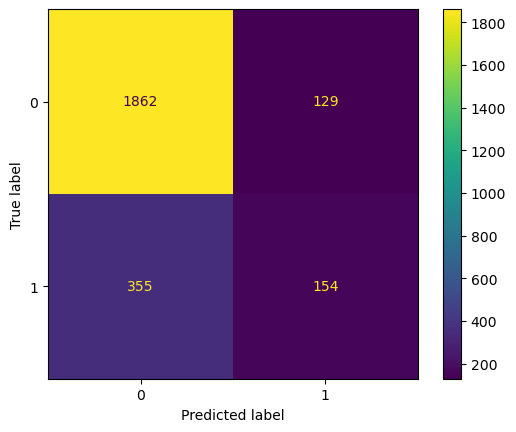

In [40]:
cm = confusion_matrix(y_test, y_scaled_preds, labels = clf.classes_)
viz = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = clf.classes_)
viz.plot()

All of our model metrics can be derived from the confusion matrix, and each metric tells its own part of the story. What stands out most in the confusion matrix is that the model misses a lot of customers who will churn. In other words, there are a lot of false negatives—355, to be exact. This is why our recall score is only 0.303.

Would we use this model? It depends. For one thing, we'd certainly want to develop other models to see if they perform better. 